# Cài đặt các thư viện cần thiết cho việc tính toán toán học và dựng đồ họa

In [1]:
!pip install pandas-stubs scikit-image matplotlib seaborn jinja2

In [10]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# Cấu hình giao diện đồ thị chuyên nghiệp
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Đường dẫn tài nguyên hệ thống
INPUT_DIR = 'images'
OUTPUT_DIR = 'results'
CSV_MAIN = os.path.join(OUTPUT_DIR, 'csv/complete_benchmark.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [11]:
df_speed = pd.read_csv(CSV_MAIN)

print(df_speed.columns.tolist())

['Timestamp', 'Image_Name', 'Sigma_S', 'Sigma_R', 'Gaussian_Time (s)', 'Standard_Time (s)', 'O1_Paper_Time (s)', 'O1_vs_Standard_PSNR (dB)', 'O1_vs_Standard_SSIM']


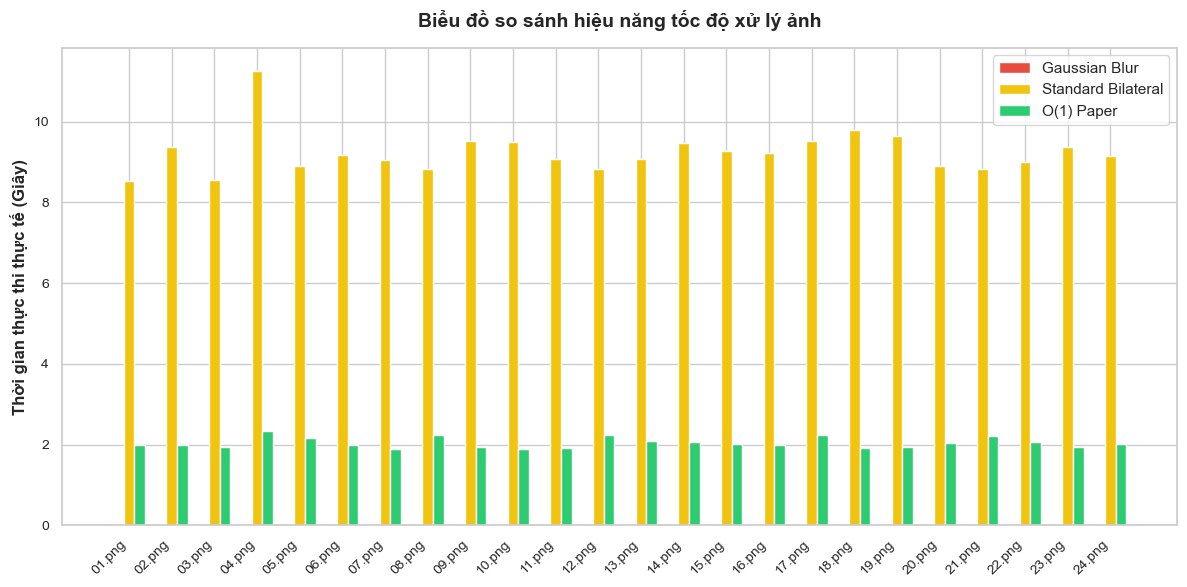

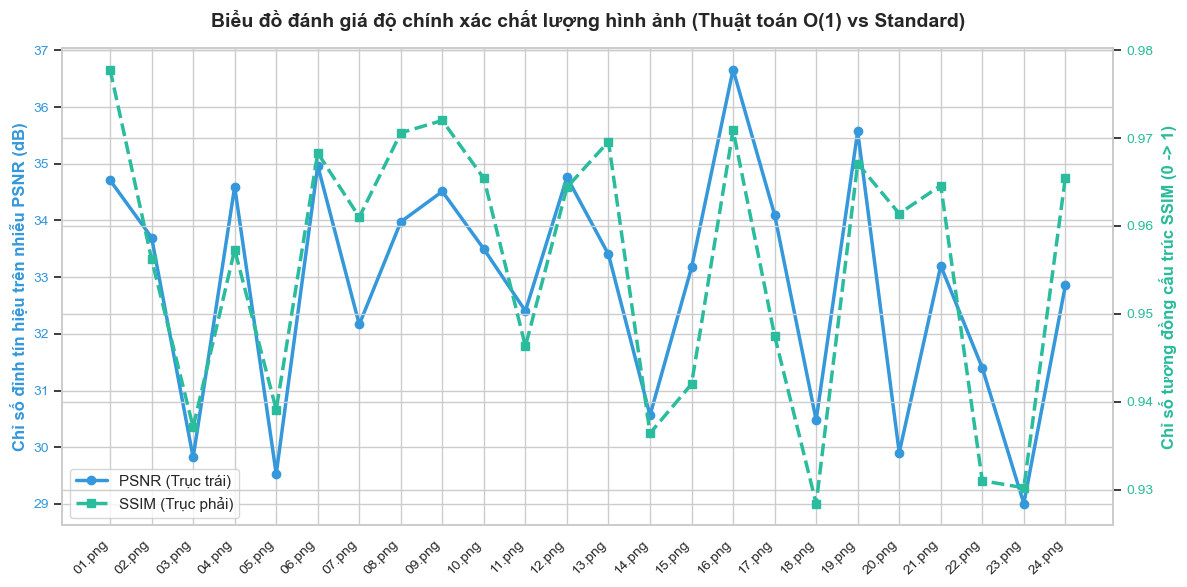

------------------------------------------------------------------------------------------
[XONG] Biểu đồ tốc độ xử lý đã xuất tại : results\charts\speed_comparison_chart.png
[XONG] Biểu đồ độ chính xác đã xuất tại: results\charts\accuracy_metrics_chart.png
------------------------------------------------------------------------------------------


In [12]:
# Cell 2: Đọc file CSV từ mục csv/ và dựng các biểu đồ hiệu năng, độ chính xác vào mục charts/
if os.path.exists(CSV_MAIN):
    df_speed = pd.read_csv(CSV_MAIN)

    # Định nghĩa đường dẫn tới mục charts nằm trong results
    CHART_DIR = os.path.join(OUTPUT_DIR, 'charts')
    os.makedirs(CHART_DIR, exist_ok=True)

    # =========================================================================
    # BIỂU ĐỒ 1: SO SÁNH HIỆU NĂNG TỐC ĐỘ (THỜI GIAN CHẠY)
    # =========================================================================
    plt.figure(figsize=(12, 6))
    x = np.arange(len(df_speed['Image_Name']))
    width = 0.25

    plt.bar(x - width, df_speed['Gaussian_Time (s)'], width, label='Gaussian Blur', color='#e74c3c')
    plt.bar(x, df_speed['Standard_Time (s)'], width, label='Standard Bilateral', color='#f1c40f')
    plt.bar(x + width, df_speed['O1_Paper_Time (s)'], width, label='O(1) Paper', color='#2ecc71')

    plt.ylabel('Thời gian thực thi thực tế (Giây)', fontweight='bold')
    plt.title('Biểu đồ so sánh hiệu năng tốc độ xử lý ảnh', fontweight='bold', pad=15)
    plt.xticks(x, df_speed['Image_Name'], rotation=45, ha='right')
    plt.legend(frameon=True)
    plt.tight_layout()

    # Lưu biểu đồ tốc độ vào mục results/charts/
    speed_chart_path = os.path.join(CHART_DIR, 'speed_comparison_chart.png')
    plt.savefig(speed_chart_path, dpi=300)
    plt.show()
    plt.close()

    # =========================================================================
    # BIỂU ĐỒ 2: ĐÁNH GIÁ ĐỘ CHÍNH XÁC ĐỒ HỌA (PSNR & SSIM SONG SONG)
    # =========================================================================
    fig, ax1 = plt.subplots(figsize=(12, 6))

    # Thiết lập mốc tọa độ x trước để tránh lỗi FixedLocator của Matplotlib
    x_ticks = np.arange(len(df_speed['Image_Name']))
    ax1.set_xticks(x_ticks)
    ax1.set_xticklabels(df_speed['Image_Name'], rotation=45, ha='right')

    # Trục Y bên trái: Biểu diễn chỉ số toán học PSNR
    color_psnr = '#3498db'
    ax1.set_ylabel('Chỉ số đỉnh tín hiệu trên nhiễu PSNR (dB)', color=color_psnr, fontweight='bold')
    line1 = ax1.plot(x_ticks, df_speed['O1_vs_Standard_PSNR (dB)'],
                     marker='o', linewidth=2.5, color=color_psnr, label='PSNR (Trục trái)')
    ax1.tick_params(axis='y', labelcolor=color_psnr)

    # Trục Y bên phải: Biểu diễn chỉ số cấu trúc thị giác SSIM
    ax2 = ax1.twinx()
    color_ssim = '#2abc9c'
    ax2.set_ylabel('Chỉ số tương đồng cấu trúc SSIM (0 -> 1)', color=color_ssim, fontweight='bold')
    line2 = ax2.plot(x_ticks, df_speed['O1_vs_Standard_SSIM'],
                     marker='s', linewidth=2.5, color=color_ssim, linestyle='--', label='SSIM (Trục phải)')
    ax2.tick_params(axis='y', labelcolor=color_ssim)

    # Gộp chung Legend của cả hai đồ thị đường
    lines = line1 + line2
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc='lower left', frameon=True)

    plt.title('Biểu đồ đánh giá độ chính xác chất lượng hình ảnh (Thuật toán O(1) vs Standard)', fontweight='bold', pad=15)
    plt.tight_layout()

    # Lưu biểu đồ độ chính xác vào mục results/charts/
    accuracy_chart_path = os.path.join(CHART_DIR, 'accuracy_metrics_chart.png')
    plt.savefig(accuracy_chart_path, dpi=300)
    plt.show()
    plt.close()

    print("-" * 90)
    print(f"[XONG] Biểu đồ tốc độ xử lý đã xuất tại : {speed_chart_path}")
    print(f"[XONG] Biểu đồ độ chính xác đã xuất tại: {accuracy_chart_path}")
    print("-" * 90)
else:
    print(f"[CẢNH BÁO] Không tìm thấy file dữ liệu tại đường dẫn cấu hình mới: {CSV_MAIN}")
    print("Hãy đảm bảo bạn đã cập nhật lại đường dẫn lưu file CSV trong file main.py sang mục results/csv/ và chạy lại nó.")